In [2]:
import numpy as np
import pandas as pd
import os
from allensdk.ephys.ephys_extractor import EphysSweepFeatureExtractor
import seaborn as sns
from itertools import groupby
from matplotlib import pyplot as plt
import shutil
import sys
sys.path.insert(0, r'C:\Users\nVoke\PycharmProjects\pythonProject1\tools')
from scan import scan_file
from mutiple_group_test import my_oneWayAnova
sample_rate=20000
'''
reference: https://allensdk.readthedocs.io/en/latest/_static/examples/nb/cell_types.html
'''

C:\Users\nVoke\AppData\Roaming\Python\Python38\site-packages\statsmodels\compat\pandas.py:61: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import Int64Index as NumericIndex


In [3]:
inhibitory_neuron=pd.read_excel(r'F:\jcy\humen_brain\electrophysiology\all_nerons\properties_AP_inhibitory.xlsx')
inhibitory_list=inhibitory_neuron['cell_name']
excitory_neuron=pd.read_excel(r'F:\jcy\humen_brain\electrophysiology\all_nerons\properties_AP_excitory.xlsx')
excitory_list=excitory_neuron['cell_name']
print(len(excitory_list))

38


In [4]:
root_rheobase=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_first_spike'
outpath=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification'
file_AP=[x for x in os.listdir(root_rheobase) if x.endswith('rheobase.txt')]
file_group=[list(g) for k, g in groupby(file_AP, lambda x:x[:8])]
print(file_group)
df = pd.read_csv(root_rheobase+'\\'+file_group[0][10], sep='\t')
df.head()

[['frontal_lobe_0817_cell3_rheobase.txt', 'frontal_lobe_0817_cell4_rheobase.txt', 'frontal_lobe_0822_cell11_rheobase.txt', 'frontal_lobe_0822_cell12_rheobase.txt', 'frontal_lobe_0822_cell14_rheobase.txt', 'frontal_lobe_0822_cell5_rheobase.txt', 'frontal_lobe_0822_cell9_rheobase.txt', 'frontal_lobe_1024_cell2_rheobase.txt', 'frontal_lobe_1024_cell3_rheobase.txt', 'frontal_lobe_1024_cell5_rheobase.txt', 'frontal_lobe_1024_cell6_rheobase.txt', 'frontal_lobe_1123_cell10_rheobase.txt', 'frontal_lobe_1123_cell11_rheobase.txt', 'frontal_lobe_1123_cell12_rheobase.txt', 'frontal_lobe_1123_cell13_rheobase.txt', 'frontal_lobe_1123_cell14_rheobase.txt', 'frontal_lobe_1123_cell15_rheobase.txt', 'frontal_lobe_1123_cell17_rheobase.txt', 'frontal_lobe_1123_cell18_rheobase.txt', 'frontal_lobe_1123_cell19_rheobase.txt', 'frontal_lobe_1123_cell21_rheobase.txt', 'frontal_lobe_1123_cell22_rheobase.txt', 'frontal_lobe_1123_cell23_rheobase.txt', 'frontal_lobe_1123_cell24_rheobase.txt', 'frontal_lobe_1123_cel

,time,sweep1,sweep4,sweep6
0,996.900024,-57.922363,-57.464600,-57.586670
1,996.950012,-57.891846,-57.525635,-57.495117
2,997.000000,-57.861328,-57.617188,-57.586670
3,997.049988,-57.952881,-57.617188,-57.586670
4,997.099976,-58.044434,-57.403564,-57.495117


<center>suprathreshold current injections induced spike<center>

In [ ]:

sweep_num=6
properties_rheobase_all=[]
for n,groups in enumerate(file_group[:]):
    rheobase_cell=[]
    # plt.figure(figsize=(8,8))
    for i in groups:
        print(i)
        valid_peak=[]
        file= pd.read_csv(root_rheobase+'\\'+i, sep='\t')
        v=file[f'sweep{sweep_num}'].values

        t = np.arange(0, len(v)) * (1.0 / sample_rate)
        stimulus= np.array(list(map(lambda x: 0, range(len(v)))))

        sweep_ext = EphysSweepFeatureExtractor(t=t, v=v, i=stimulus, start=0.04372, end=0.54372,
                                               filter=None,dv_cutoff=20,max_interval=0.005,min_height=20,min_peak=-30,thresh_frac=0.05,baseline_interval=0.1,baseline_detect_thresh=0.3)
        sweep_ext.process_spikes()

        # print("Avg spike threshold: %.01f mV" % sweep_ext.spike_feature("threshold_v").mean())
        # print("Avg spike width: %.02f ms" %  (1e3 * np.nanmean(sweep_ext.spike_feature("width"))))
        # print(sweep_ext.spike_feature_keys())
        # print(sweep_ext.sweep_feature_keys())

        threshold_t = sweep_ext.spike_feature("threshold_t")
        threshold_v = sweep_ext.spike_feature("threshold_v")

        peak_t=sweep_ext.spike_feature("peak_t")
        peak_v=sweep_ext.spike_feature("peak_v")
        peak_i=sweep_ext.spike_feature("peak_i")
        peak_amp=peak_v-threshold_v

        trough_t=sweep_ext.spike_feature("trough_t")
        trough_v=sweep_ext.spike_feature("trough_v")
        spike_num=min(len(threshold_v),len(trough_v))
        AHPamp=threshold_v[:spike_num]-trough_v[:spike_num]

        adapt=sweep_ext.sweep_feature('adapt')
        latency=sweep_ext.sweep_feature('latency')
        print(f'latency:{latency}')
        isi_cv=sweep_ext.sweep_feature('isi_cv')
        avg_rate=sweep_ext.sweep_feature('avg_rate')
        v_baseline=sweep_ext.sweep_feature('v_baseline')

        # downstroke=sweep_ext.spike_feature("downstroke")
        # downstroke_t=sweep_ext.spike_feature("downstroke_t")
        # downstroke_v=sweep_ext.spike_feature("downstroke_v")
        # slow_trough_t=sweep_ext.spike_feature("slow_trough_t")
        # slow_trough_v=sweep_ext.spike_feature("slow_trough_v")
        # adp_t=sweep_ext.spike_feature("adp_t")
        # adp_v=sweep_ext.spike_feature("adp_v")
        # adp_i=sweep_ext.spike_feature("adp_i")

        width=sweep_ext.spike_feature("width")
        upstroke_downstroke_ratio=sweep_ext.spike_feature("upstroke_downstroke_ratio")

        properties_rheobase=[i[:13],i[:-13],np.mean(threshold_v),latency,np.mean(peak_v),np.mean(trough_v),np.mean(peak_amp),np.mean(width),np.mean(upstroke_downstroke_ratio),np.mean(adapt),np.mean(AHPamp),isi_cv,avg_rate,v_baseline]
        properties_rheobase_all.append(properties_rheobase)

        # fig = plt.figure()
        # p = plt.plot(t, v, color='black')
        # min_v = v.min()
        # v_level = min_v - 5
        # plt.scatter(peak_t,peak_v,s=8, c='r')
        # plt.scatter(trough_t,trough_v,s=8, c='g')

pra_AP=pd.DataFrame(properties_rheobase_all)
pra_AP.columns=['brain_region','cell_name','threshold_v','latency','peak_v','trough_v','peak_amp','width','upstroke_downstroke_ratio','adaptation','AHPamp','isi_cv','avg_rate','v_baseline']
pra_AP.to_excel(outpath+'\\properties_rheobase_humen.xlsx',index=None)

frontal_lobe_0817_cell3_rheobase.txt
latency:0.002829999999999999
frontal_lobe_0817_cell4_rheobase.txt
latency:0.016579999999999998
frontal_lobe_0822_cell11_rheobase.txt
latency:0.010480000000000003
frontal_lobe_0822_cell12_rheobase.txt
latency:0.08482999999999999
frontal_lobe_0822_cell14_rheobase.txt
latency:0.07848
frontal_lobe_0822_cell5_rheobase.txt
latency:0.05128
frontal_lobe_0822_cell9_rheobase.txt
latency:0.03868
frontal_lobe_1024_cell2_rheobase.txt
latency:0.23412999999999998


C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_index"] = vals
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:211: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_i"] = self.i[vals]
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` wil

frontal_lobe_1024_cell3_rheobase.txt
latency:0.02053
frontal_lobe_1024_cell5_rheobase.txt
latency:0.06238
frontal_lobe_1024_cell6_rheobase.txt
latency:0.06942999999999999
frontal_lobe_1123_cell10_rheobase.txt
latency:0.020380000000000002
frontal_lobe_1123_cell11_rheobase.txt
latency:0.005330000000000001
frontal_lobe_1123_cell12_rheobase.txt
latency:0.009030000000000003
frontal_lobe_1123_cell13_rheobase.txt
latency:0.0029800000000000035
frontal_lobe_1123_cell14_rheobase.txt
latency:0.0031800000000000023
frontal_lobe_1123_cell15_rheobase.txt


C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_index"] = vals
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:211: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_i"] = self.i[vals]
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` wil

latency:0.008530000000000003
frontal_lobe_1123_cell17_rheobase.txt
latency:0.01788
frontal_lobe_1123_cell18_rheobase.txt
latency:0.004930000000000004
frontal_lobe_1123_cell19_rheobase.txt
latency:0.08448
frontal_lobe_1123_cell21_rheobase.txt
latency:0.005630000000000003
frontal_lobe_1123_cell22_rheobase.txt
latency:0.004430000000000003
frontal_lobe_1123_cell23_rheobase.txt
latency:0.015780000000000002
frontal_lobe_1123_cell24_rheobase.txt
latency:0.0035299999999999984
frontal_lobe_1123_cell25_rheobase.txt


...

C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_index"] = vals
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:211: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_i"] = self.i[vals]
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` wil

latency:0.0018799999999999997
temporal_lobe_1109_cell9_rheobase.txt
latency:0.004180000000000003
temporal_lobe_1118_cell10_rheobase.txt
latency:0.026530000000000005
temporal_lobe_1118_cell11_rheobase.txt
latency:0.044680000000000004
temporal_lobe_1118_cell12_rheobase.txt
latency:0.016030000000000003
temporal_lobe_1118_cell13_rheobase.txt
latency:0.005330000000000001
temporal_lobe_1118_cell14_rheobase.txt
latency:0.025479999999999996
temporal_lobe_1118_cell15_rheobase.txt
latency:0.02228
temporal_lobe_1118_cell16_rheobase.txt
latency:0.0033299999999999996
temporal_lobe_1118_cell18_rheobase.txt
latency:0.01693
temporal_lobe_1118_cell19_rheobase.txt
latency:0.031080000000000003
temporal_lobe_1118_cell1_rheobase.txt
latency:0.004180000000000003
temporal_lobe_1118_cell20_rheobase.txt
latency:0.005330000000000001
temporal_lobe_1118_cell2_rheobase.txt
latency:0.00383
temporal_lobe_1118_cell3_rheobase.txt
latency:0.004029999999999999
temporal_lobe_1118_cell4_rheobase.txt
latency:0.026729999999

C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_index"] = vals
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:211: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_i"] = self.i[vals]
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` wil

temporal_lobe_1118_cell6_rheobase.txt
latency:0.04768000000000001
temporal_lobe_1118_cell8_rheobase.txt
latency:0.026530000000000005
temporal_lobe_1118_cell9_rheobase.txt
latency:0.003380000000000001


C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_index"] = vals
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:211: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  spikes_df.loc[valid_ind, k + "_i"] = self.i[vals]
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_extractor.py:203: FutureWarning: In a future version, `df.iloc[:, i] = newvals` wil

In [19]:
'''
properties of rheobase
'''
print(f'number of inhibitory neurons:{len(inhibitory_list)}')
rheobase_pro =pd.read_excel(outpath+'\\properties_rheobase_humen.xlsx')
null_cell2=[i for i in inhibitory_list if i not in list(rheobase_pro['cell_name'])]
print(np.array(null_cell2).reshape(-1,1))
rheobase_pro=rheobase_pro[rheobase_pro['cell_name'].isin(inhibitory_list)]

number of inhibitory neurons:95
[]


参数threshold_v统计学差异：
Significant difference between the groups
frontal_lobe_ <= occipital_lob <= temporal_lobe
参数latency统计学差异：
Significant difference between the groups
frontal_lobe_ <= occipital_lob < temporal_lobe
参数peak_v统计学差异：
Significant difference between the groups
frontal_lobe_ <= occipital_lob < temporal_lobe
参数trough_v统计学差异：
Significant difference between the groups
frontal_lobe_ <= occipital_lob <= temporal_lobe
参数peak_amp统计学差异：
Significant difference between the groups
frontal_lobe_ <= occipital_lob < temporal_lobe
参数width统计学差异：
NO significant difference between the groups
frontal_lobe_ <= occipital_lob <= temporal_lobe
参数upstroke_downstroke_ratio统计学差异：
Significant difference between the groups
occipital_lob <= frontal_lobe_ < temporal_lobe
参数adaptation统计学差异：
NO significant difference between the groups
occipital_lob <= temporal_lobe <= frontal_lobe_
参数AHPamp统计学差异：
NO significant difference between the groups
frontal_lobe_ <= occipital_lob <= temporal_lobe
参数isi_cv统计学差异：
NO 

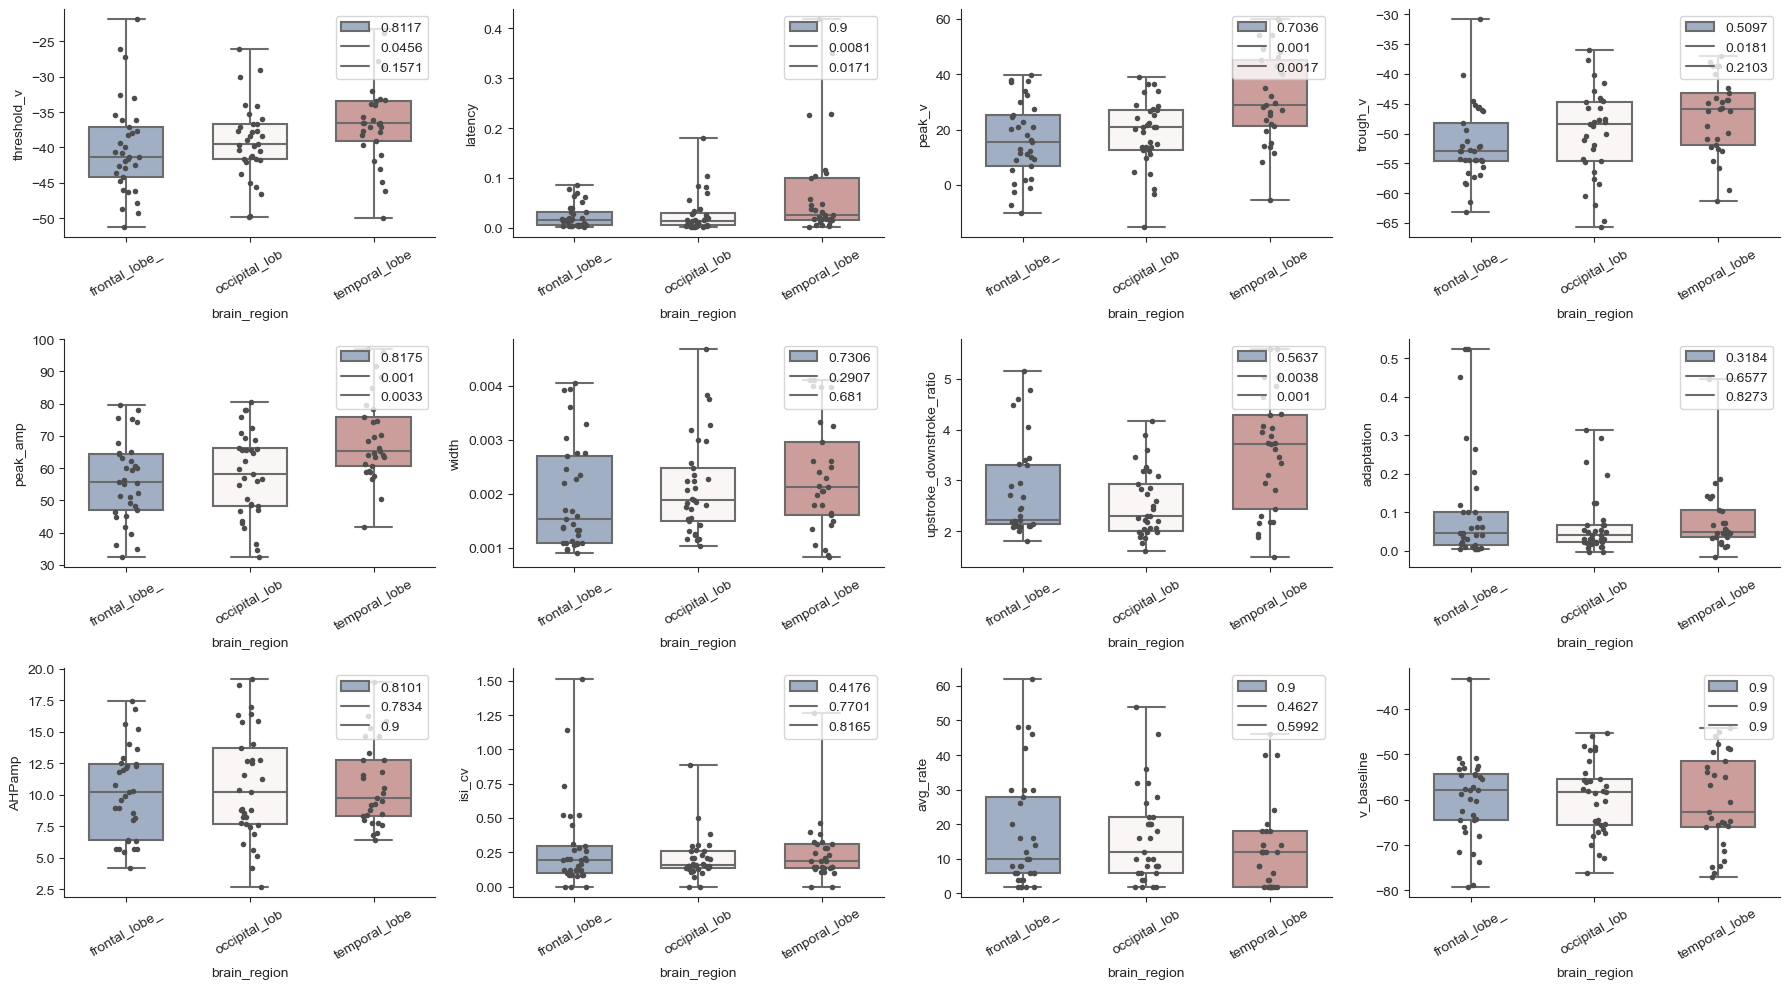

In [ ]:
###missing values were impute with last value in same column
rheobase_pro.fillna(method = 'pad', axis =0, inplace=True, limit=None)
rheobase_pro=rheobase_pro[rheobase_pro['cell_name'].isin(inhibitory_list)]

para=['threshold_v','latency','peak_v','trough_v','peak_amp','width','upstroke_downstroke_ratio','adaptation','AHPamp','isi_cv','avg_rate','v_baseline']
f, ax = plt.subplots(nrows=3, ncols=4,figsize=(18, 10))
sns.set_style(style="ticks")
for i,parameters in enumerate(para):
    print(f'Parameter {parameters}：')
    diff1,diff2=my_oneWayAnova(rheobase_pro,cata_name='brain_region',num_name=parameters)
    plt.subplot(3,4,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="brain_region", y=parameters, data=rheobase_pro,whis=[0, 100], width=.6, palette="vlag")
    plt.legend(diff2['p-adj'],loc=1)
    # Add in points to show each observation
    sns.stripplot(x="brain_region", y=parameters, data=rheobase_pro,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)

f.tight_layout()
plt.savefig(outpath+'\\properties_rheobase_humen.pdf')

<center>hyperpolarizing induced features analysis<center>

In [7]:
from allensdk.ephys.ephys_extractor import EphysSweepFeatureExtractor
root_ir=r'F:\jcy\humen_brain\electrophysiology\all_nerons\sag_rebound'

file_AP=[x for x in os.listdir(root_ir) if x.endswith('IR.txt')]
file_group=[list(g) for k, g in groupby(file_AP, lambda x:x[:8])]
properties_IR_all=[]
inject_num=1
for n,groups in enumerate(file_group[:]):
    ir_cell=[]
    for i in groups:
        # print(i)
        valid_peak=[]
        file= pd.read_csv(root_ir+'\\'+i, sep='\t')
        v=file[f'inject{inject_num}'].values

        t = np.arange(0, len(v)) * (1.0 / sample_rate)
        stimulus= np.array(list(map(lambda x: 0, range(len(v)))))
        sweep_ext = EphysSweepFeatureExtractor(t=t, v=v, i=stimulus, start=0.5203, end=0.7703,
                                               filter=None,dv_cutoff=20,max_interval=0.005,min_height=20,min_peak=-30,thresh_frac=0.05,baseline_interval=0.1,baseline_detect_thresh=0.3)
        sweep_ext.process_spikes()

        v_baseline=sweep_ext._get_baseline_voltage()
        tau=sweep_ext.estimate_time_constant()
        sag=sweep_ext.estimate_sag()
        Rin=sweep_ext.input_resistance()
        Cm=tau/Rin

        properties_IR=[i[:13],i[:-7],tau,sag,-Rin,Cm]
        properties_IR_all.append(properties_IR)

pra_IR=pd.DataFrame(properties_IR_all)
pra_IR.columns=['brain_region','cell_name','tau','sag','Rin','Cm']
pra_IR.to_excel(outpath+'\\properties_IR_humen.xlsx',index=None)
print('finished!')

C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_features.py:820: RuntimeWarning: invalid value encountered in sqrt
  rsme = np.sqrt(np.mean(pred - v_window))
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_features.py:820: RuntimeWarning: invalid value encountered in sqrt
  rsme = np.sqrt(np.mean(pred - v_window))
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_features.py:820: RuntimeWarning: invalid value encountered in sqrt
  rsme = np.sqrt(np.mean(pred - v_window))
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_features.py:820: RuntimeWarning: invalid value encountered in sqrt
  rsme = np.sqrt(np.mean(pred - v_window))
C:\ProgramData\Anaconda3\envs\ephy__project\lib\site-packages\allensdk\ephys\ephys_features.py:820: RuntimeWarning: invalid value encountered in sqrt
  rsme = np.sqrt(np.mean(pred - v_window))
C:\ProgramData\Anaconda3\envs\ephy_

finished!


In [10]:
'''
membrane_properties
'''
root_dir=outpath
membrane_pro =pd.read_excel(root_dir+'\\properties_IR_humen.xlsx')
null_cell3=[i for i in inhibitory_list if i not in list(membrane_pro['cell_name'])]
print(np.array(null_cell3).reshape(-1,1))
membrane_pro=membrane_pro[membrane_pro['cell_name'].isin(inhibitory_list)]

[]


Index(['brain_region', 'cell_name', 'tau', 'sag', 'Rin', 'Cm'], dtype='object')
参数tau统计学差异：
Significant difference between the groups
occipital_lob < frontal_lobe_ <= temporal_lobe
参数sag统计学差异：
NO significant difference between the groups
frontal_lobe_ <= occipital_lob <= temporal_lobe
参数Rin统计学差异：
NO significant difference between the groups
temporal_lobe <= frontal_lobe_ <= occipital_lob
参数Cm统计学差异：
Significant difference between the groups
temporal_lobe < frontal_lobe_ <= occipital_lob


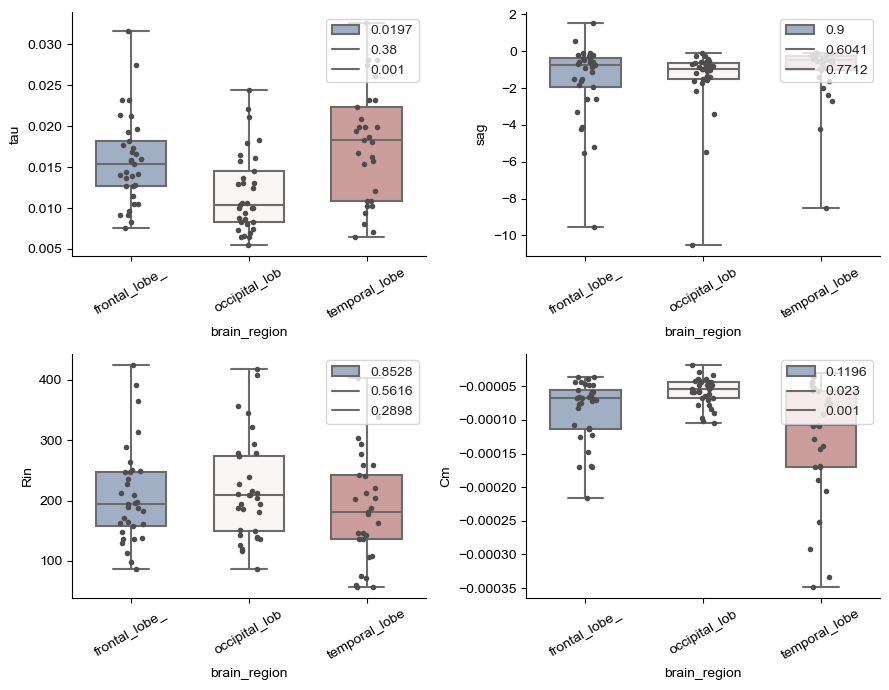

In [11]:
membrane_pro.fillna(method = 'pad', axis =0, inplace=True, limit=None)
membrane_pro=membrane_pro[membrane_pro['cell_name'].isin(inhibitory_list)]

para=['tau','sag','Rin','Cm']
print(membrane_pro.columns)
f, ax = plt.subplots(nrows=2, ncols=2,figsize=(9,7))
sns.set_style(style="ticks")
for i,parameters in enumerate(para):
    print(f'参数{parameters}统计学差异：')
    diff1,diff2=my_oneWayAnova(membrane_pro,cata_name='brain_region',num_name=parameters)
    plt.subplot(2,2,i+1)
    # Plot the orbital period with horizontal boxes
    sns.boxplot(x="brain_region", y=parameters, data=membrane_pro,whis=[0, 100], width=.6, palette="vlag")
    plt.legend(diff2['p-adj'],loc=1)
    # Add in points to show each observation
    sns.stripplot(x="brain_region", y=parameters, data=membrane_pro,size=4, color=".3", linewidth=0)
    sns.despine()
    plt.xticks(rotation=30)

f.tight_layout()
plt.savefig(root_dir+'\\properties_IR_humen.pdf')

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
# import umap.umap_ as umap
import umap.plot

In [27]:
outpath=r'F:\jcy\humen_brain\electrophysiology\all_nerons\rheobase_quntification'

subthreshold =pd.read_excel(outpath+'\\properties_IR_humen.xlsx')
subthreshold=subthreshold[subthreshold['cell_name'].isin(excitory_list)]
non_overlap1=[i for i in excitory_list if i not in subthreshold['cell_name'].values]
print(f'mismatch_cel_id1:{np.array(non_overlap1).reshape(-1, 1)}')

suprathreshold=pd.read_excel(outpath+'\\properties_rheobase_humen.xlsx')
suprathreshold=suprathreshold[suprathreshold['cell_name'].isin(excitory_list)]
non_overlap2=[i for i in excitory_list if i not in suprathreshold['cell_name'].values]
print(f'mismatch_cel_id1:{np.array(non_overlap2).reshape(-1, 1)}')

intrinsical_electro=pd.merge(suprathreshold,subthreshold,on='cell_name')

df_copy=intrinsical_electro.drop(['brain_region_x','brain_region_y'],axis='columns' ) ##删除这两列
df_copy.to_excel(outpath+'\\intrinsical_electro_summary(excitory).xlsx',index=None)
print(intrinsical_electro.head())

mismatch_cel_id1:[['frontal_lobe_0818_cell5']
 ['occipital_lobe_0814_cell1']
 ['occipital_lobe_1121_cell11']
 ['occipital_lobe_1202_cell13']]
mismatch_cel_id1:[['frontal_lobe_0818_cell5']
 ['occipital_lobe_0814_cell1']
 ['occipital_lobe_0904_cell5']
 ['occipital_lobe_1121_cell11']
 ['occipital_lobe_1202_cell14']
 ['temporal_lobe_0909_cell10']
 ['temporal_lobe_1118_cell17']]
  brain_region_x                 cell_name  threshold_v  latency     peak_v  \
0  frontal_lobe_  frontal_lobe_0822_cell11   -41.912079  0.01048  26.649475   
1  frontal_lobe_   frontal_lobe_1024_cell2   -35.003662  0.23413  29.937744   
2  frontal_lobe_  frontal_lobe_1123_cell15   -50.689697  0.00853  -7.049561   
3  frontal_lobe_  frontal_lobe_1123_cell26   -34.729004  0.00378  12.908936   
4  frontal_lobe_   frontal_lobe_1207_cell2   -38.299561  0.08448  20.782471   

    trough_v   peak_amp     width  upstroke_downstroke_ratio  adaptation  \
0 -54.687500  68.561554  0.004493                   5.887151    0.035255

In [44]:
summary_features=pd.read_excel(outpath+'\\intrinsical_electro_summary.xlsx',index_col=0)
# summary_features=summary_features.drop('Fire_rate',axis='columns')
'''缺失值填充为该列上一个元素'''
summary_features.fillna(method = 'pad', axis =0, inplace=True, limit=None)
summary_features=pd.DataFrame(summary_features)
summary_features.head()

,threshold_v,latency,peak_v,trough_v,peak_amp,width,upstroke_downstroke_ratio,adaptation,AHPamp,isi_cv,avg_rate,v_baseline,tau,sag,Rin,Cm
cell_name,,,,,,,,,,,,,,,,
frontal_lobe_0817_cell3,-42.917887,0.00283,-1.251221,-45.242310,41.666667,0.003300,2.705182,0.119155,8.951823,0.119155,6,-62.500802,0.021332,0.028546,188.478088,-0.000113
frontal_lobe_0817_cell4,-21.911621,0.01658,37.546794,-30.863444,59.458415,0.003033,4.601620,0.450772,8.951823,0.450772,6,-33.337367,0.012819,0.023905,86.830139,-0.000148
frontal_lobe_0822_cell12,-41.585286,0.08483,38.035075,-48.202515,79.620361,0.002350,4.783333,0.523371,6.362915,0.523371,6,-67.108887,0.014026,0.015761,130.184784,-0.000108
frontal_lobe_0822_cell14,-27.191162,0.07848,12.268066,-58.288574,39.459229,0.004050,2.222222,0.523371,6.362915,0.523371,2,-73.666434,0.023142,0.008447,135.791168,-0.000170
frontal_lobe_0822_cell5,-36.114502,0.05128,39.562988,-52.966309,75.677490,0.001690,3.304838,0.060612,16.851807,0.161467,10,-64.422538,0.017661,0.036933,288.649597,-0.000061


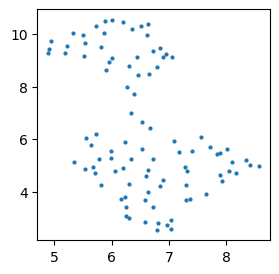

In [51]:
sum_fea_scaler=StandardScaler().fit_transform(summary_features)
sum_fea_scaler=pd.DataFrame(sum_fea_scaler,index=summary_features.index,columns=summary_features.columns)
umap_vals = umap.UMAP(n_neighbors=15,n_components=2).fit_transform(sum_fea_scaler)

plt.figure(figsize=(3,3))
plt.scatter(*umap_vals.T,s=4,edgecolors=None)
# sns.despine()

In [52]:
path=r'F:\jcy\humen_brain\electrophysiology\all_nerons'
file_inhibitory=pd.read_excel(path+'\\properties_firing.xlsx',sheet_name='inhibitory')
pv_cell=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb')]  ###& (file_inhibitory['brain_region']=='occipital_lobe'
pv_cell=list(pv_cell['cell_name'])

occi_pv=file_inhibitory[(file_inhibitory['cell_type_identify']=='Pvalb') & (file_inhibitory['brain_region']=='occipital_lobe')]
occi_pv=list(occi_pv['cell_name'])
print(np.array(occi_pv).reshape(-1,1))

[['occipital_lobe_1121_cell4']
 ['occipital_lobe_1121_cell6']
 ['occipital_lobe_1121_cell14']
 ['occipital_lobe_1202_cell20']
 ['occipital_lobe_1202_cell23']
 ['occipital_lobe_1202_cell27']
 ['occipital_lobe_1206_cell7']
 ['occipital_lobe_1206_cell14']]


In [53]:
pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in pv_cell]
occip_pv_cluster=[i[0] for i in enumerate(sum_fea_scaler.index) if i[1] in occi_pv]
print(occip_pv_cluster)
[i for i in occi_pv if i not in list(sum_fea_scaler.index)]

[40, 43, 44, 50, 53, 59, 63]


['occipital_lobe_1202_cell27']

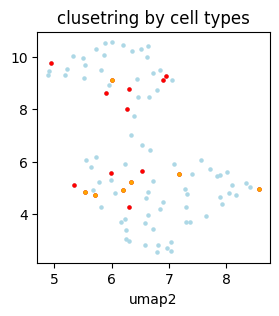

In [54]:
plt.figure(figsize=(3,3))
plt.scatter(*umap_vals.T,s=5,c='lightblue',edgecolors=None)
plt.scatter(*umap_vals[pv_cluster,:].T,s=5,c='r',edgecolors=None)
plt.scatter(*umap_vals[occip_pv_cluster,:].T,s=5,c='orange',edgecolors=None)
# for i in enumerate(list(sum_fea_scaler.index)):
#     plt.annotate(i[1][-11:],umap_vals[i[0],:],textcoords='offset points')

plt.title('clusetring by cell types');plt.xlabel('umap1');plt.xlabel('umap2')
# sns.despine()
plt.savefig(outpath+'\\clusetring by cell types.pdf')

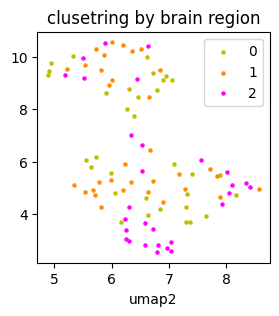

In [55]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
sum_fea_scaler['tagets']=[i[:8] for i in sum_fea_scaler.index]
tagets=sum_fea_scaler['tagets']
encoder = LabelEncoder()
tagets = encoder.fit_transform(tagets)
encoder.classes_, np.unique(tagets, return_counts=True)
plt.figure(figsize=(3,3))
for color, i in zip(['y','darkorange','magenta'], [0, 1, 2]):
    plt.scatter(umap_vals[tagets==i, 0], umap_vals[tagets==i, 1],s=5, c=color, label=i)
    plt.legend()
plt.title('clusetring by brain region');plt.xlabel('umap1');plt.xlabel('umap2')
plt.savefig(outpath+'\\clusetring by brain region.pdf')

Index(['threshold_v', 'latency', 'peak_v', 'trough_v', 'peak_amp', 'width',
       'upstroke_downstroke_ratio', 'adaptation', 'AHPamp', 'isi_cv',
       'avg_rate', 'v_baseline', 'tau', 'sag', 'Rin', 'Cm'],
      dtype='object')


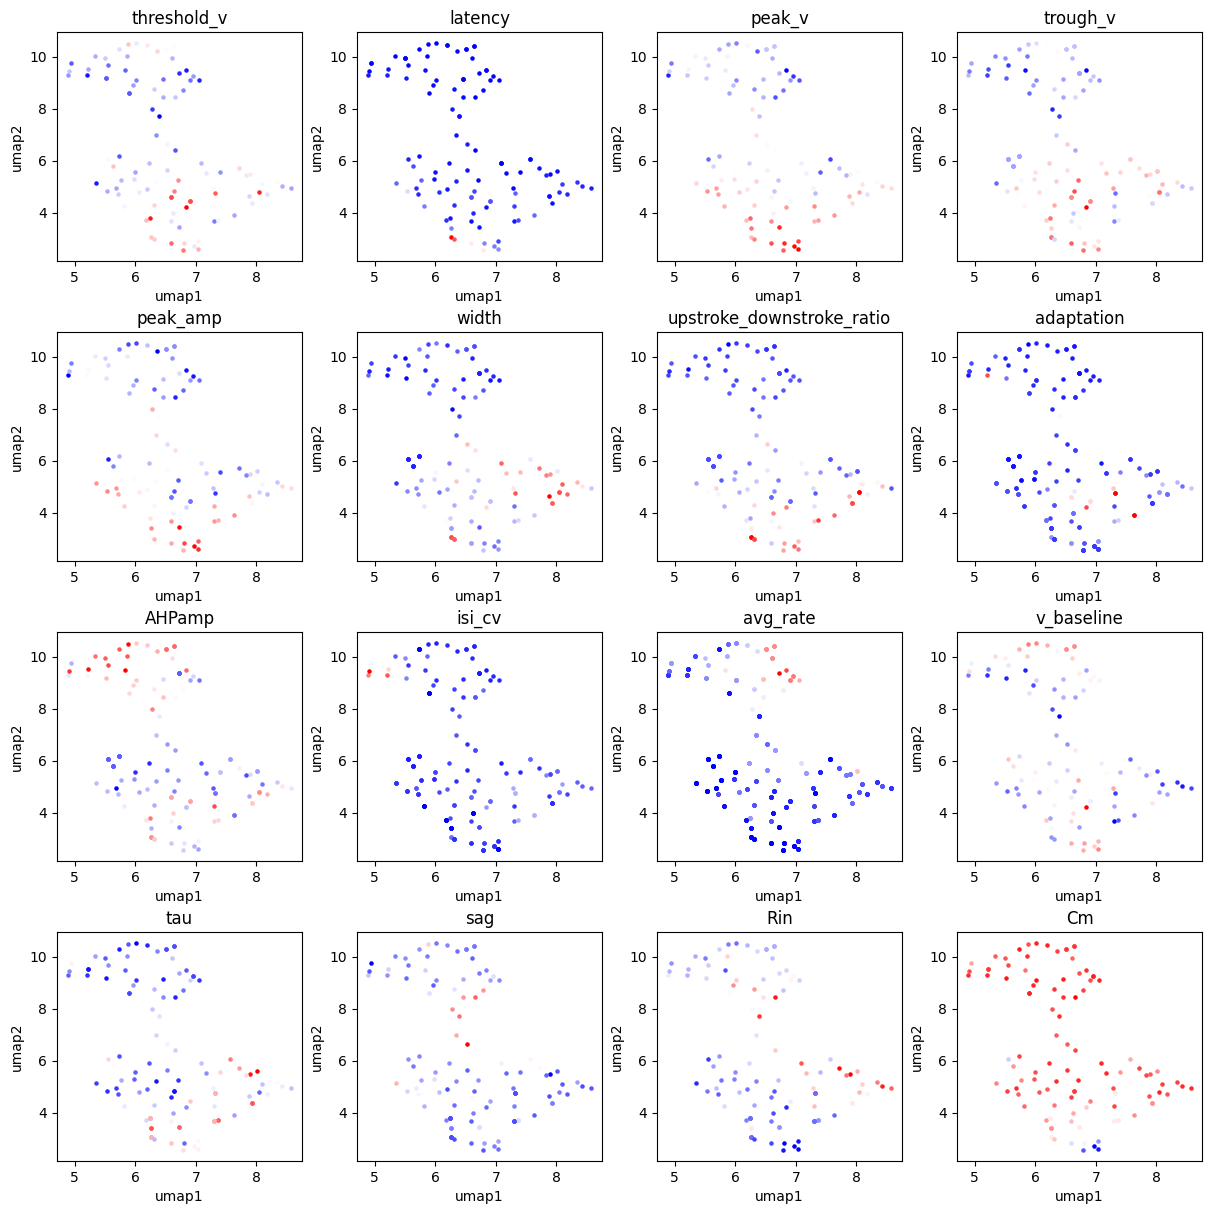

In [56]:
import numpy
import matplotlib.cm as cmap
###将颜色数值映射到颜色
parameters=sum_fea_scaler.columns[:-1]
print(parameters)
plt.subplots(nrows=4, ncols=4, figsize=(12,12),constrained_layout=True)
for i in enumerate(parameters):
    r =sum_fea_scaler[i[1]].values
    c = cmap.bwr(numpy.int_((r-r.min())/r.ptp()*255))
    plt.subplot(4,4,i[0]+1)
    for color, cell in zip(c, r):
        plt.scatter(umap_vals[r==cell, 0], umap_vals[r==cell, 1],s=5, c=np.array(color).reshape(1,-1))
    plt.title(i[1]);plt.xlabel('umap1');plt.ylabel('umap2')
plt.savefig(outpath+'\\clusetring by parameters.pdf')